In [20]:
!pip install xgboost

  Using cached xgboost-3.0.5-py3-none-manylinux_2_28_x86_64.whl.metadata (2.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 MB 9.8 MB/s eta 0:00:000m eta 0:00:010:00:01m


In [21]:
# Imports
import os
import glob
from collections import Counter
import joblib
import cv2

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from xgboost import XGBClassifier, plot_importance, plot_tree

from skimage.feature import hog
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve

In [11]:
# file path
IMG_SIZE = 128
DATA_PATH = "../Data/Scores"

In [12]:
# Load dataset
paths, labels = [], []
for shape_name in sorted(os.listdir(DATA_PATH)):
    shape_path = os.path.join(DATA_PATH, shape_name)
    if not os.path.isdir(shape_path):
        continue
    for score in sorted(os.listdir(shape_path)):
        score_path = os.path.join(shape_path, score)
        if not os.path.isdir(score_path):
            continue
        label = f"{shape_name}_{score}"
        for ext in ("*.png", "*.jpg", "*.jpeg"):
            for p in glob.glob(os.path.join(score_path, ext)):
                paths.append(p)
                labels.append(label)

df = pd.DataFrame({"path": paths, "label": labels})
print("[INFO] Total files found:", len(df))

[INFO] Total files found: 4297


In [13]:
# Class distribution
counts = Counter(df['label'])
print("[INFO] Example class counts (first 8):", list(counts.items())[:8])

[INFO] Example class counts (first 8): [('Circle_0', 5), ('Circle_2', 1), ('Circle_3', 112), ('Circle_4', 457), ('Diagonal_0', 4), ('Diagonal_3', 2), ('Diagonal_4', 70), ('Diagonal_5', 479)]


In [15]:
# Feature extraction (HOG + Hu moments + area)
def extract_features(path, img_size=IMG_SIZE):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (img_size, img_size))
    # HOG
    hog_feats = hog(img, orientations=9, pixels_per_cell=(8,8),
                    cells_per_block=(2,2), block_norm='L2-Hys', feature_vector=True)
    # Hu Moments
    moments = cv2.moments(img)
    hu_feats = cv2.HuMoments(moments).flatten()
    # Area (sum of pixels / 255)
    area = [np.sum(img) / 255.0]
    return np.hstack([hog_feats, hu_feats, area])

print("[INFO] Extracting features (this may take a while)...")
features = []
for p in tqdm(df['path'], desc="Extracting"):
    features.append(extract_features(p))
X = np.vstack(features)
y_labels = np.array(df['label'])
print("[INFO] Feature matrix shape:", X.shape)

[INFO] Extracting features (this may take a while)...


Extracting: 100%|██████████| 4297/4297 [00:47<00:00, 89.60it/s]

[INFO] Feature matrix shape: (4297, 8108)


In [16]:
# Encode labels
le = LabelEncoder()
y = le.fit_transform(y_labels)
print("[INFO] Total classes:", len(le.classes_))

[INFO] Total classes: 34


In [17]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print("[INFO] Train size:", X_train.shape[0], "Test size:", X_test.shape[0])

[INFO] Train size: 3437 Test size: 860


In [18]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
# Train XGBoost
num_classes = len(np.unique(y))
print("[INFO] Number of target classes:", num_classes)

xgb_clf = XGBClassifier(
    objective='multi:softprob',
    num_class=num_classes,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist', 
    use_label_encoder=False,
    eval_metric='mlogloss',
    eval_metric=["error", "logloss"],
    random_state=42,
    n_jobs=-1
)

print("[INFO] Training XGBoost...")
xgb_clf.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

[INFO] Number of target classes: 34
[INFO] Training XGBoost...


/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [00:43:40] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1, num_class=34, ...)

In [36]:
# Evaluation
y_pred = xgb_clf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc:.4f}")

present_labels = np.unique(y_test)
target_names = [le.classes_[i] for i in present_labels]

report_dict = classification_report(
    y_test, y_pred,
    labels=present_labels,
    target_names=target_names,
    output_dict=True
)
print(classification_report(
    y_test, y_pred,
    labels=np.unique(y_test),
    target_names=le.classes_[np.unique(y_test)]
))

#report_df = pd.DataFrame(report_dict).transpose()


Test Accuracy: 0.7395
                      precision    recall  f1-score   support

            Circle_3       0.00      0.00      0.00        26
            Circle_4       0.74      0.98      0.84       100
          Diagonal_0       0.00      0.00      0.00         1
          Diagonal_4       0.00      0.00      0.00        15
          Diagonal_5       0.85      0.95      0.90       100
 Overlapped circle_0       0.00      0.00      0.00         1
 Overlapped circle_5       0.33      0.03      0.05        34
 Overlapped circle_6       0.69      0.96      0.81        85
Overlapped pencils_0       0.00      0.00      0.00         2
Overlapped pencils_3       0.00      0.00      0.00         1
Overlapped pencils_4       0.00      0.00      0.00         6
Overlapped pencils_5       0.64      0.23      0.33        31
Overlapped pencils_6       0.55      0.84      0.67        43
            Square_4       0.00      0.00      0.00         9
            Square_5       0.92      0.99     

/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

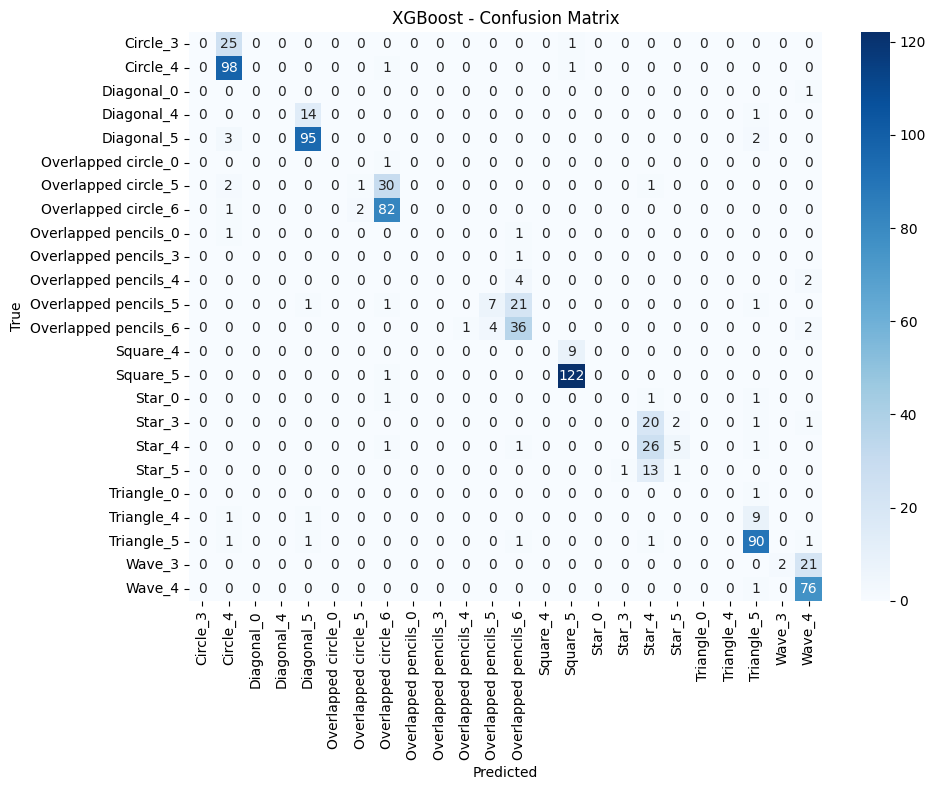

In [39]:
# Confusion matrix Show
cm = confusion_matrix(y_test, y_pred, labels=present_labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("XGBoost - Confusion Matrix")
plt.tight_layout()

plt.show()

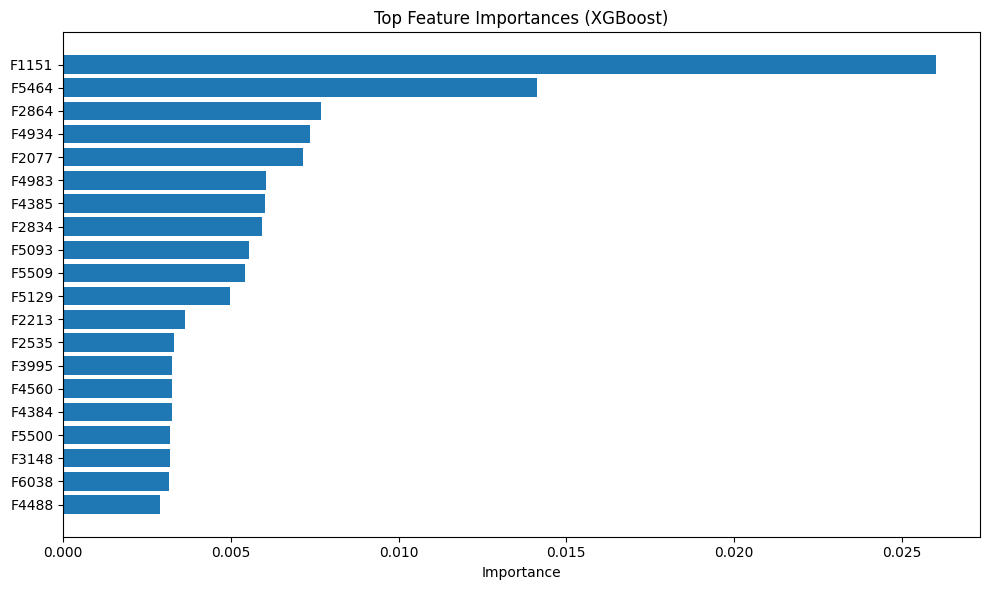

In [40]:
# Feature importance (gain) and plot (top 20)
importances = xgb_clf.feature_importances_ 
indices = np.argsort(importances)[-20:] if importances.size >= 20 else np.argsort(importances)

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [f"F{i}" for i in indices])
plt.xlabel("Importance")
plt.title("Top Feature Importances (XGBoost)")
plt.tight_layout()

plt.show()

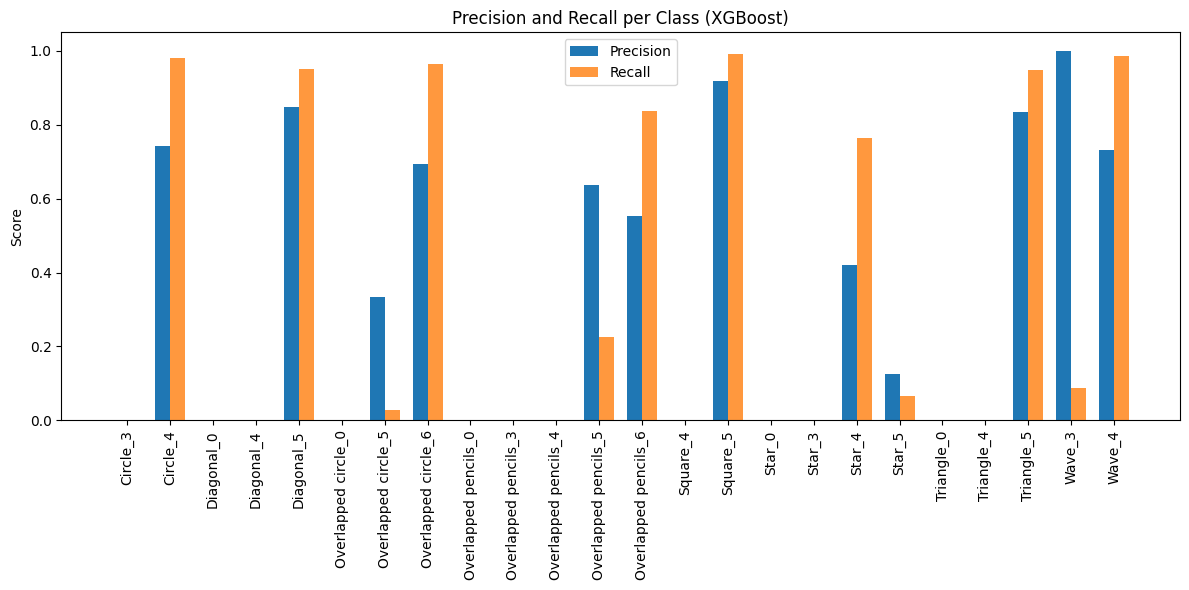

In [41]:
# Precision & Recall
class_rows = report_df.loc[target_names]

plt.figure(figsize=(12,6))
x = np.arange(len(class_rows))
width = 0.35
plt.bar(x - width/2, class_rows['precision'], width, label='Precision')
plt.bar(x + width/2, class_rows['recall'], width, label='Recall', alpha=0.8)
plt.xticks(x, class_rows.index, rotation=90)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Precision and Recall per Class (XGBoost)")
plt.legend()
plt.tight_layout()

plt.show()

In [42]:
# XGBoost Training Curve
results = xgb_clf.evals_result()

plt.figure(figsize=(8,5))
plt.plot(results['validation_0']['mlogloss'], label='Validation Loss')
plt.plot(results['validation_0']['mlogloss'], 'o-', markersize=2, alpha=0.6)
plt.xlabel("Boosting Rounds (Epochs)")
plt.ylabel("Multi-class Log Loss")
plt.title("XGBoost Training Loss Curve")
plt.legend()
plt.tight_layout()

plt.show()

XGBoostError: No evaluation result, `eval_set` is not used during training.

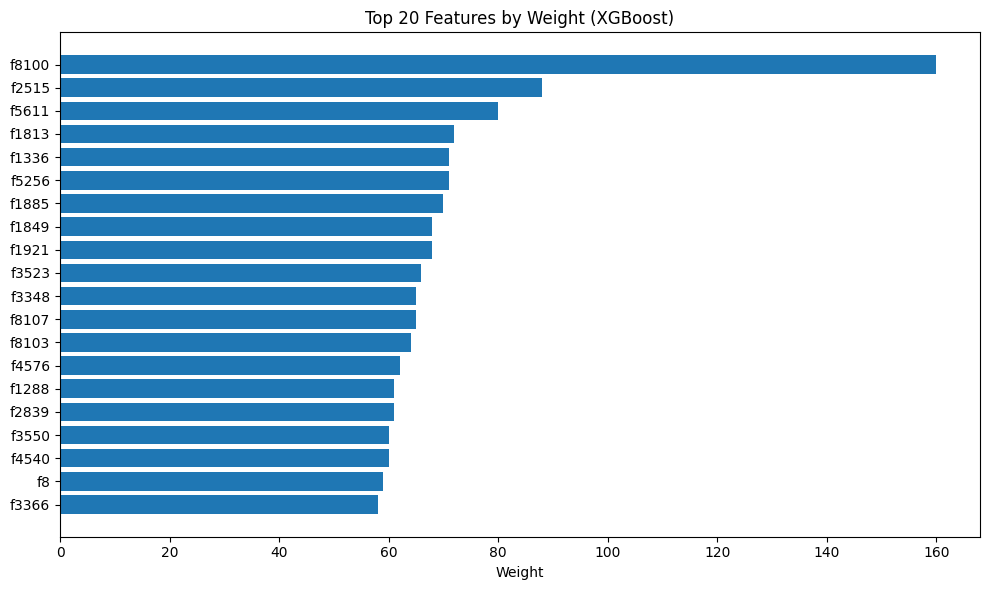

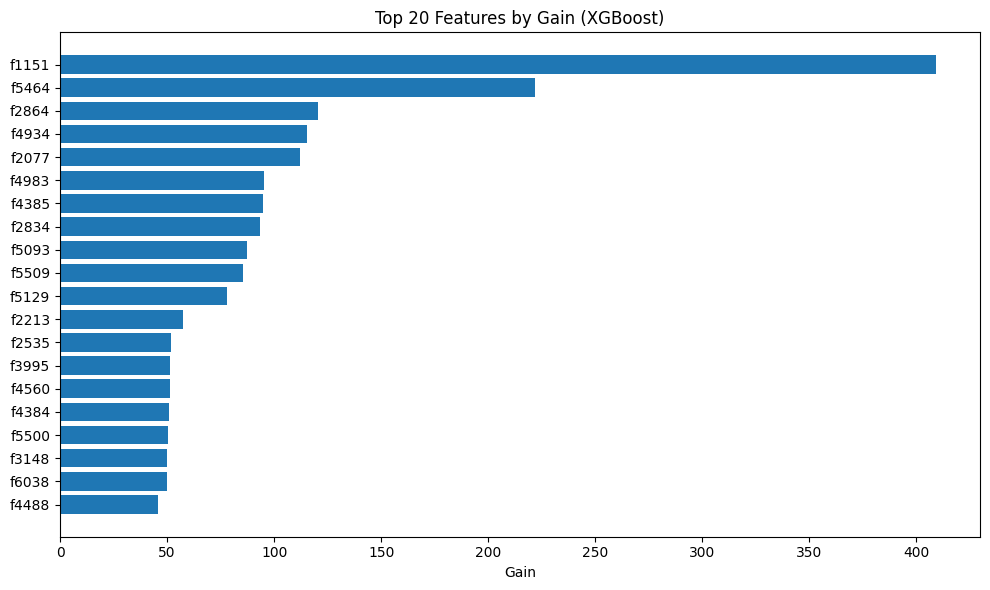

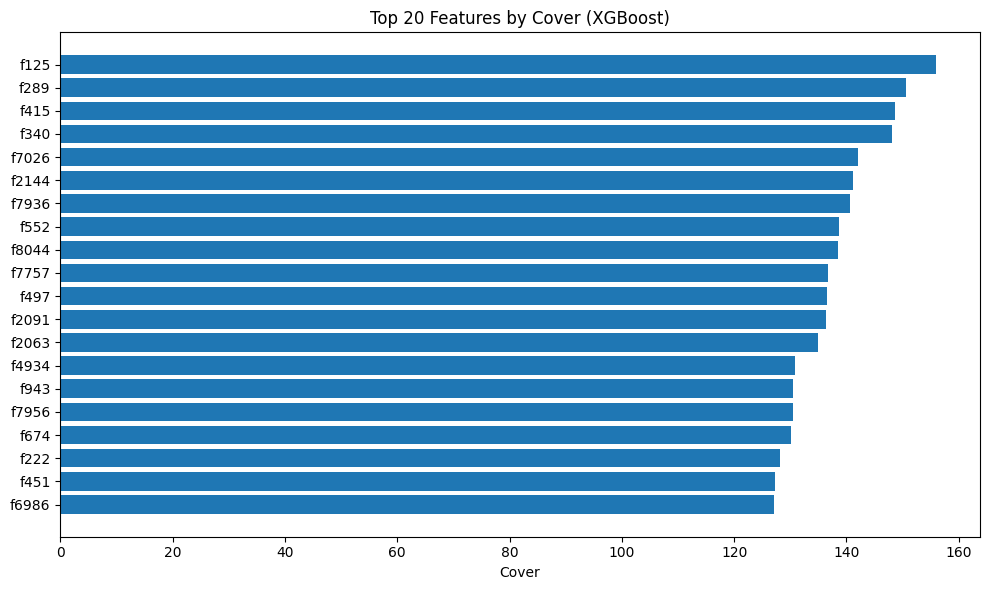

In [43]:
# XGBoost Feature Importances by Type
booster = xgb_clf.get_booster()
importance_types = ['weight', 'gain', 'cover']

for imp_type in importance_types:
    importance = booster.get_score(importance_type=imp_type)
    if not importance:
        continue
    sorted_imp = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:20]
    keys, values = zip(*sorted_imp)
    
    plt.figure(figsize=(10,6))
    plt.barh(keys[::-1], values[::-1])
    plt.xlabel(imp_type.capitalize())
    plt.title(f"Top 20 Features by {imp_type.capitalize()} (XGBoost)")
    plt.tight_layout()
    
    plt.show()

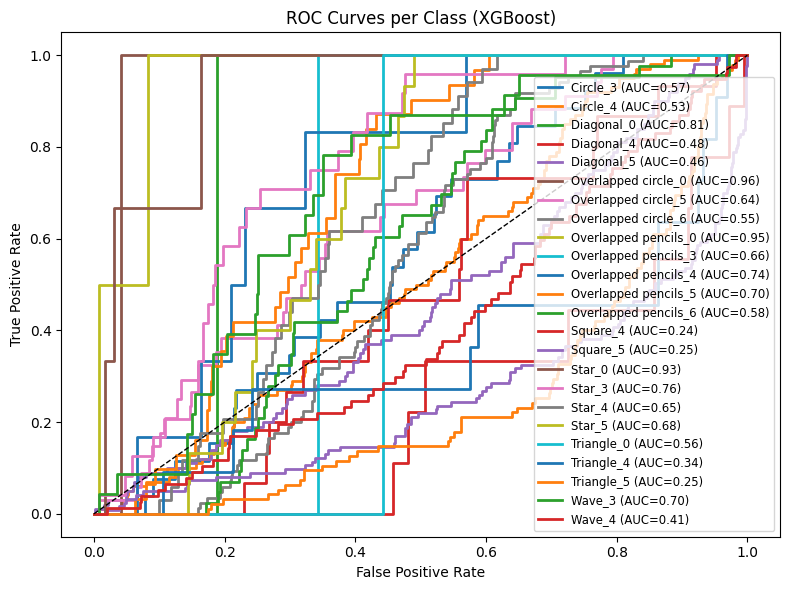

In [44]:
# Binarize labels for ROC
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
y_proba = xgb_clf.predict_proba(X_test_scaled)

plt.figure(figsize=(8,6))
for i, class_name in enumerate(target_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{class_name} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves per Class (XGBoost)")
plt.legend(fontsize='small')
plt.tight_layout()

plt.show()

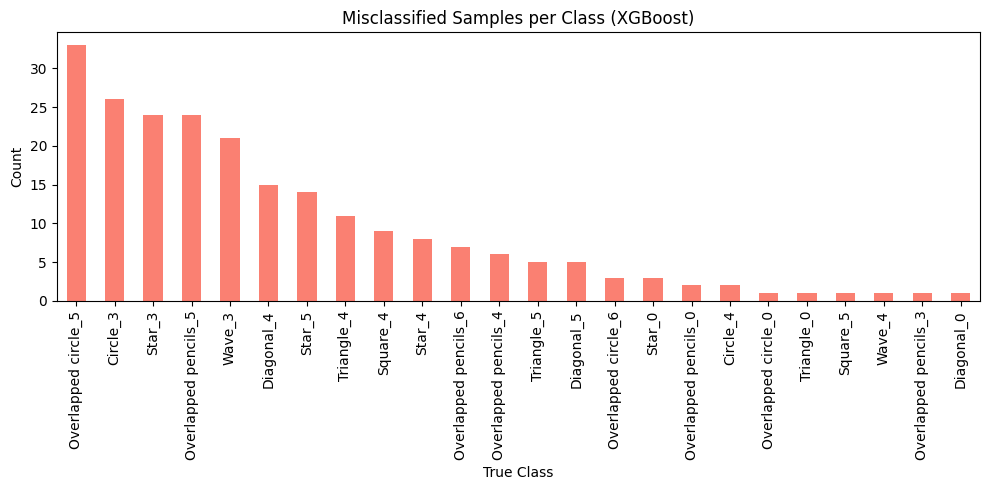

In [45]:
# Misclassification Counts
misclassified = y_test != y_pred
mis_labels = pd.Series(le.inverse_transform(y_test[misclassified]))
plt.figure(figsize=(10,5))
mis_labels.value_counts().plot(kind='bar', color='salmon')
plt.title("Misclassified Samples per Class (XGBoost)")
plt.ylabel("Count")
plt.xlabel("True Class")
plt.tight_layout()

plt.show()

In [25]:
# Save Model
SAVE_DIR = "./model_outputs/XGBoost"
os.makedirs(SAVE_DIR, exist_ok=True)

In [32]:
# Save model
model_path = os.path.join(SAVE_DIR, "XGB_model.pkl")
joblib.dump(xgb_clf, model_path)
print(f"[SAVED] GB model → {model_path}")

[SAVED] GB model → ./model_outputs/XGBoost/XGB_model.pkl


In [33]:
# confusion matrix save
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10,8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("XGBoost - Normalized Confusion Matrix")
plt.tight_layout()
cm_norm_path = os.path.join(SAVE_DIR, "confusion_matrix_normalized.png")
plt.savefig(cm_norm_path, dpi=150)
plt.close()
print(f"[SAVED] Normalized Confusion Matrix → {cm_norm_path}")

[SAVED] Normalized Confusion Matrix → ./model_outputs/XGBoost/confusion_matrix_normalized.png


In [34]:
# Feature importance save
importances = xgb_clf.feature_importances_ 
indices = np.argsort(importances)[-20:] if importances.size >= 20 else np.argsort(importances)

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [f"F{i}" for i in indices])
plt.xlabel("Importance")
plt.title("Top Feature Importances (XGBoost)")
plt.tight_layout()
feat_path = os.path.join(SAVE_DIR, "feature_importance.png")
plt.savefig(feat_path, dpi=150)
plt.close()
print(f"[SAVED] Feature Importance → {feat_path}")

[SAVED] Feature Importance → ./model_outputs/XGBoost/feature_importance.png


In [35]:
# Precision & Recall
class_rows = report_df.loc[target_names]

plt.figure(figsize=(12,6))
x = np.arange(len(class_rows))
width = 0.35
plt.bar(x - width/2, class_rows['precision'], width, label='Precision')
plt.bar(x + width/2, class_rows['recall'], width, label='Recall', alpha=0.8)
plt.xticks(x, class_rows.index, rotation=90)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Precision and Recall per Class (XGBoost)")
plt.legend()
plt.tight_layout()
pr_path = os.path.join(SAVE_DIR, "precision_recall_per_class.png")
plt.savefig(pr_path, dpi=150)
plt.close()
print(f"[SAVED] Precision/Recall chart → {pr_path}")

[SAVED] Precision/Recall chart → ./model_outputs/XGBoost/precision_recall_per_class.png
